In [35]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent  # Adjusts for notebook being in src/visualization/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.visualization import get_evaluation_metrics, visualize_agent_survival
from src.visualization.utils import AgentMetrics

methods = {
    "RAPPO (global prior)": [
        Path("../../results/loss_curves/rappo_fixed_prior_2026_20_02/CustomPPO_0_1dfbd_2026-02-20_13-53-13.csv"),
        Path("../../results/loss_curves/rappo_fixed_prior_2026_20_02/CustomPPO_0_21af4_2026-02-20_13-53-19.csv"),
        Path("../../results/loss_curves/rappo_fixed_prior_2026_20_02/CustomPPO_0_40fd7_2026-02-20_13-54-12.csv"),
        Path("../../results/loss_curves/rappo_fixed_prior_2026_20_02/CustomPPO_0_440d0_2026-02-20_13-54-17.csv"),
        Path("../../results/loss_curves/rappo_fixed_prior_2026_20_02/CustomPPO_0_41414_2026-02-20_13-54-12.csv"),
    ],
    "RAPPO (no prior)": [
        Path("../../results/loss_curves/rappo_no_prior_2026_20_02/CustomPPO_0_639c8_2026-02-20_13-55-10.csv"),
        Path("../../results/loss_curves/rappo_no_prior_2026_20_02/CustomPPO_0_4128a_2026-02-20_13-54-12.csv"),
        Path("../../results/loss_curves/rappo_no_prior_2026_20_02/CustomPPO_0_6343e_2026-02-20_13-55-09.csv"),
        Path("../../results/loss_curves/rappo_no_prior_2026_20_02/CustomPPO_0_61990_2026-02-20_13-55-06.csv"),
        Path("../../results/loss_curves/rappo_no_prior_2026_20_02/CustomPPO_0_64197_2026-02-20_13-55-10.csv"),
    ],
}


Processing: RAPPO (global prior)

Summary Statistics for RAPPO (global prior):

Run 1:
  Steps: 1101 - 150426
  Loss range: 523.00 - 7543.00
  Final loss: 6482.00

Run 2:
  Steps: 1094 - 153251
  Loss range: 519.00 - 7954.00
  Final loss: 7873.00

Run 3:
  Steps: 1078 - 150745
  Loss range: 519.00 - 8064.00
  Final loss: 7323.00

Run 4:
  Steps: 1093 - 151279
  Loss range: 522.00 - 7843.00
  Final loss: 7402.00

Run 5:
  Steps: 1087 - 152497
  Loss range: 519.00 - 7962.00
  Final loss: 7498.00

Aggregated across 5 runs:
  Interpolated points: 79
  Step range: 1101 - 150426
  Final mean loss: 6332.94 ± 549.17

Processing: RAPPO (no prior)

Summary Statistics for RAPPO (no prior):

Run 1:
  Steps: 1094 - 120672
  Loss range: 519.00 - 8064.00
  Final loss: 8048.00

Run 2:
  Steps: 1101 - 120402
  Loss range: 523.00 - 7315.00
  Final loss: 4610.00

Run 3:
  Steps: 1093 - 119977
  Loss range: 522.00 - 7697.00
  Final loss: 7619.00

Run 4:
  Steps: 1078 - 120584
  Loss range: 519.00 - 8023.

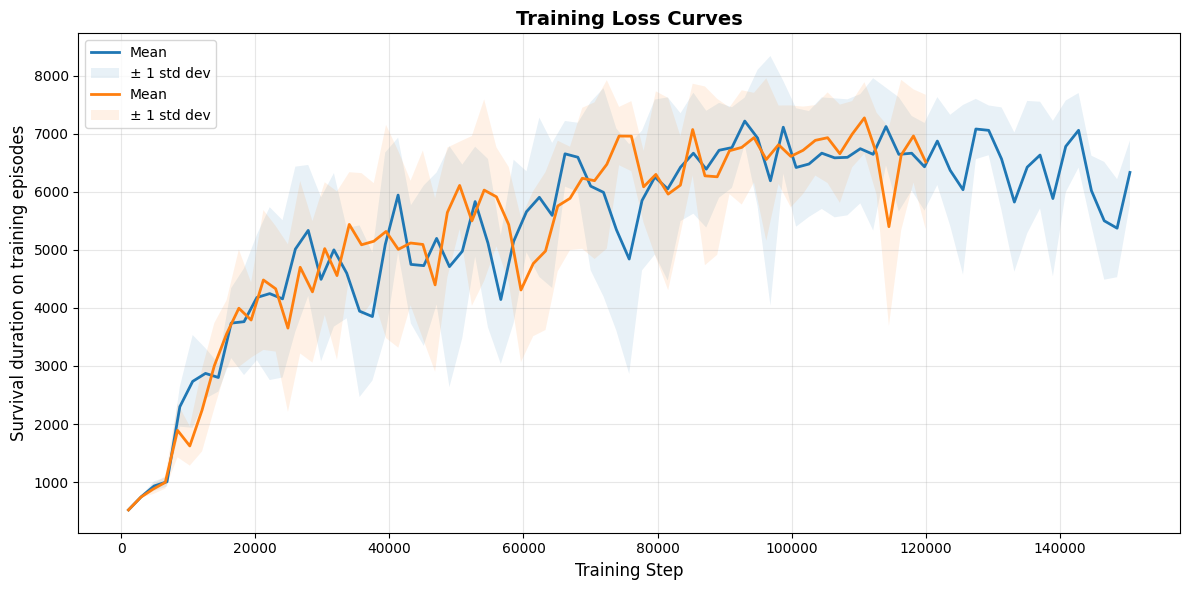

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Reset seaborn theme to default matplotlib
sns.reset_orig()
# Create the plot
plt.figure(figsize=(12, 6))

# Process each method
for method_name, csv_paths in methods.items():
    print(f"\n{'='*80}")
    print(f"Processing: {method_name}")
    print(f"{'='*80}")

    # Read all CSV files for this method
    all_curves = []
    for i, csv_path in enumerate(csv_paths):
        df = pd.read_csv(csv_path)
        df['run'] = i + 1  # Label each run
        all_curves.append(df)

    num_runs = len(all_curves)

    # Find the range of steps across all runs
    min_step = max(df['Step'].min() for df in all_curves)
    max_step = min(df['Step'].max() for df in all_curves)

    # Create a common grid of steps for interpolation
    # Use the minimum number of points from all runs for the grid
    num_points = min(len(df) for df in all_curves)
    common_steps = np.linspace(min_step, max_step, num_points)

    # Interpolate all runs to common steps and compute mean and std
    values_matrix = []
    for df in all_curves:
        df_sorted = df.sort_values('Step')
        # Interpolate values to common steps
        interpolated_values = np.interp(common_steps, df_sorted['Step'], df_sorted['Value'])
        values_matrix.append(interpolated_values)

    values_matrix = np.array(values_matrix)
    mean_values = np.mean(values_matrix, axis=0)
    std_values = np.std(values_matrix, axis=0)

    # Plot mean line
    plt.plot(common_steps, mean_values, linewidth=2, label='Mean')

    # Plot shaded area for variance (mean ± std)
    plt.fill_between(common_steps,
                     mean_values - std_values,
                     mean_values + std_values,
                     alpha=0.1,
                     label='± 1 std dev')

    # Print summary statistics
    print(f"\nSummary Statistics for {method_name}:")
    for i, df in enumerate(all_curves):
        print(f"\nRun {i+1}:")
        print(f"  Steps: {df['Step'].min()} - {df['Step'].max()}")
        print(f"  Loss range: {df['Value'].min():.2f} - {df['Value'].max():.2f}")
        print(f"  Final loss: {df['Value'].iloc[-1]:.2f}")

    print(f"\nAggregated across {num_runs} runs:")
    print(f"  Interpolated points: {len(common_steps)}")
    print(f"  Step range: {min_step} - {max_step}")
    print(f"  Final mean loss: {mean_values[-1]:.2f} ± {std_values[-1]:.2f}")

plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Survival duration on training episodes', fontsize=12)
plt.title(f'Training Loss Curves', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
methods = {
    "RAPPO (global prior)": [
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_1dfbd_2026-02-20_13-53-13/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_21af4_2026-02-20_13-53-19/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_40fd7_2026-02-20_13-54-12/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_440d0_2026-02-20_13-54-17/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_41414_2026-02-20_13-54-12/evaluations"),
    ],
    "RAPPO (no prior)": [
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_1dfbd_2026-02-20_13-53-13/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_21af4_2026-02-20_13-53-19/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_40fd7_2026-02-20_13-54-12/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_440d0_2026-02-20_13-54-17/evaluations"),
        Path("../../results/evaluations/rappo_fixed_prior_2026_20_02/CustomPPO_0_41414_2026-02-20_13-54-12/evaluations"),
    ],
}


Processing: RAPPO (global prior)


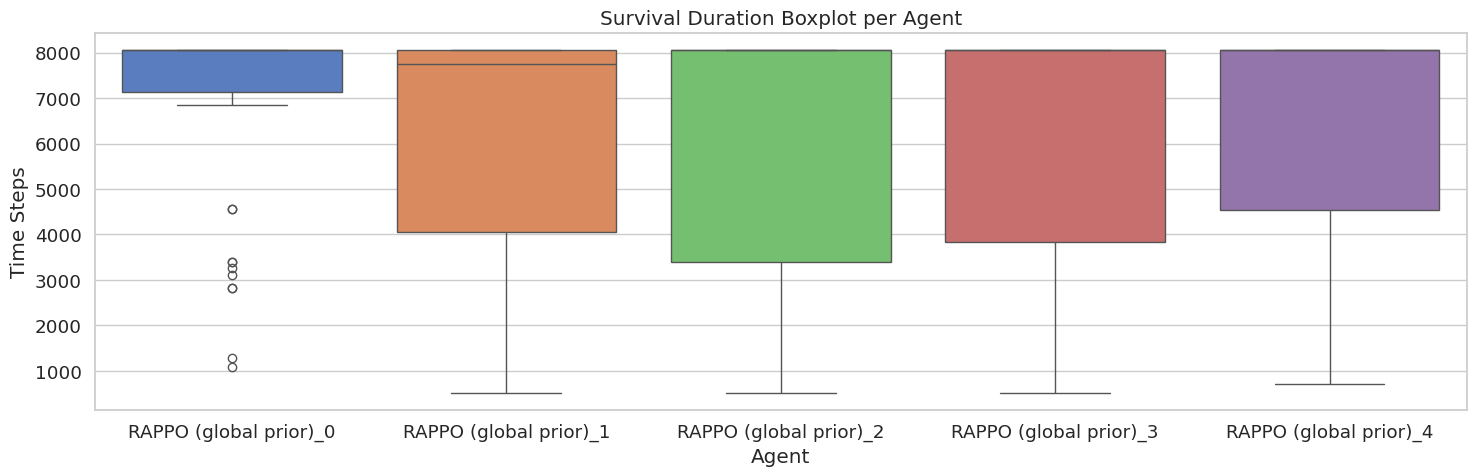

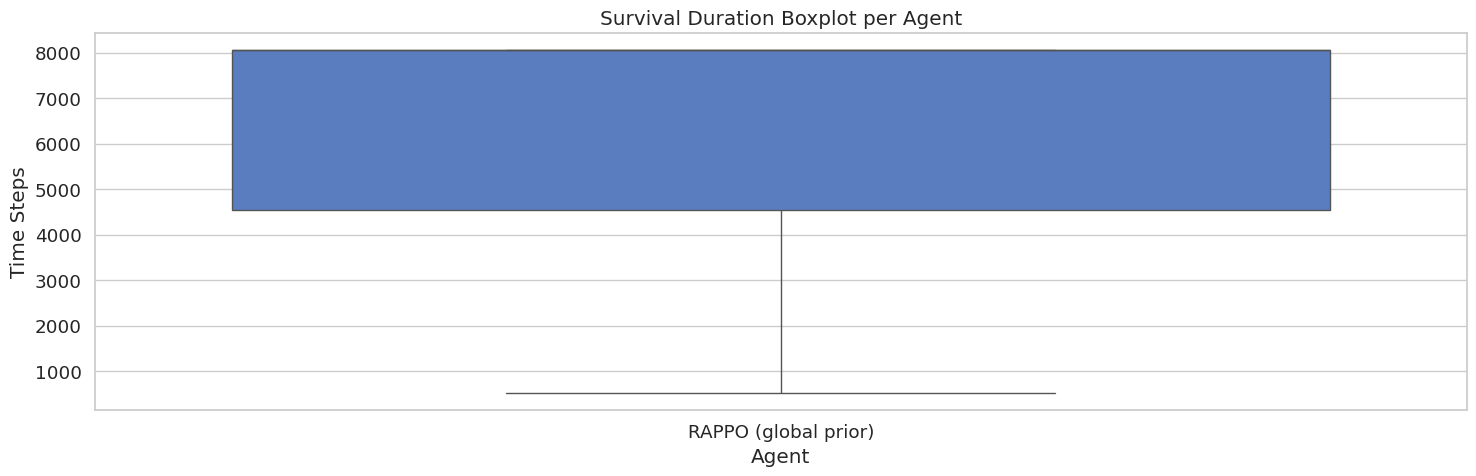

In [34]:
for method_name, paths in methods.items():
    print(f"\n{'='*80}")
    print(f"Processing: {method_name}")
    print(f"{'='*80}")
    all_evaluation_metrics = [get_evaluation_metrics(path, f"{method_name}_{i}") for i,path in enumerate(paths)]
    visualize_agent_survival(all_evaluation_metrics)
    combined_evaluation_metric = AgentMetrics(label = f"{method_name}", survival_duration = np.concatenate([m.survival_duration for m in all_evaluation_metrics]), returns = np.concatenate([m.returns for m in all_evaluation_metrics]))
    visualize_agent_survival([combined_evaluation_metric])